## Блок 1: Импорты, Seed и проверка среды

In [2]:
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Фиксация seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Настройка устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


## Блок 2: Данные и первичный анализ

In [3]:
# Загрузка датасета
dataset = load_dataset("emotion")

# Вывод информации о разбиении
print(f"Размеры частей: {dataset}")

# Вывод 3 примеров
for i in range(3):
    print(f"Текст: {dataset['train'][i]['text']} | Метка: {dataset['train'][i]['label']}")

# Краткое описание:
# В этом датасете мы классифицируем тексты на 6 эмоций:
# 0: sadness, 1: joy, 2: love, 3: anger, 4: fear, 5: surprise.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Размеры частей: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Текст: i didnt feel humiliated | Метка: 0
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake | Метка: 0
Текст: im grabbing a minute to post i feel greedy wrong | Метка: 3


## Блок 3: Токенизация

In [4]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Пример токенизации для 3 текстов
sample_texts = dataset['train'][:3]['text']
tokenized_output = tokenizer(sample_texts, padding=True, truncation=True, return_tensors="pt")

print("Пример токенизации:")
for i in range(3):
    print(f"\nТекст: {sample_texts[i]}")
    print(f"Токены: {tokenizer.convert_ids_to_tokens(tokenized_output['input_ids'][i])}")
    print(f"Input IDs: {tokenized_output['input_ids'][i]}")
    print(f"Attention Mask: {tokenized_output['attention_mask'][i]}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Пример токенизации:

Текст: i didnt feel humiliated
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs: tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0])
Attention Mask: tensor([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
Input IDs: tensor([  101,  1045,  2064,  2175,  2013,  3110,  2061, 20625,  2000,  2061,
         9636, 17772,  2074,  2013,  21

## Блок 4: Инференс готовой модели

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6).to(device)

# Тест на нескольких примерах
inputs = tokenizer(sample_texts, padding=True, truncation=True, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)
    predictions = torch.argmax(outputs.logits, dim=-1)

print(f"Предсказания модели до обучения: {predictions.cpu().numpy()}")
print("Комментарий: Модель без дообучения выдает случайные результаты, так как веса классификатора не настроены под наши 6 классов.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Предсказания модели до обучения: [1 3 1]
Комментарий: Модель без дообучения выдает случайные результаты, так как веса классификатора не настроены под наши 6 классов.


## Блок 5: Подготовка датасета и обучение (Fine-tuning)

In [8]:
# Функция токенизации для всего датасета
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Определение метрик
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {"accuracy": acc, "f1": f1}

# Настройки обучения с параметрами для сохранения лучшей модели
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",         # Выбор критерия лучшей модели
    greater_is_better=True,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir='./logs',
)

# Инициализация модели
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6).to(device)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

# Запуск обучения
trainer.train()

# Явный выбор лучшего варианта по validation
best_model_path = trainer.state.best_model_checkpoint
if best_model_path:
    print(f"Выбран лучший вариант модели из: {best_model_path}")
    model = AutoModelForSequenceClassification.from_pretrained(best_model_path).to(device)
    trainer.model = model
else:
    print("Лучшая модель не найдена, используется последняя эпоха.")

# Финальная оценка на test
test_results = trainer.evaluate(tokenized_datasets["test"])
print(f"Результаты на тесте: {test_results}")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Выбран лучший вариант модели из: ./results/checkpoint-2000


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Результаты на тесте: {'eval_loss': 0.1763075739145279, 'eval_accuracy': 0.9265, 'eval_f1': 0.8830086702138463, 'eval_runtime': 7.4242, 'eval_samples_per_second': 269.39, 'eval_steps_per_second': 16.837, 'epoch': 2.0}


## Блок 6: Оценка качества и сохранение артефактов

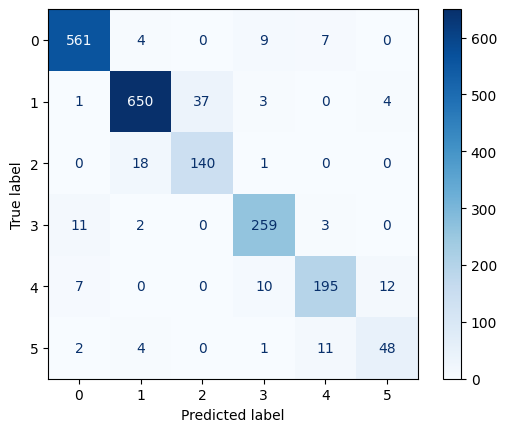

Артефакты (sample_predictions.csv и confusion_matrix.png) сохранены в текущую директорию.
Примеры предсказаний:
                                                text  true_label  pred_label
0  im feeling rather rotten so im not very ambiti...           0           0
1          im updating my blog because i feel shitty           0           0
2  i never make her separate from me because i do...           0           0
3  i left with my bouquet of red and yellow tulip...           1           1
4    i was feeling a little vain when i did this one           0           0
5  i cant walk into a shop anywhere where i do no...           4           4
6   i felt anger when at the end of a telephone call           3           3
7  i explain why i clung to a relationship with a...           1           1
8  i like to have the same breathless feeling as ...           1           1
9  i jest i feel grumpy tired and pre menstrual w...           3           3


In [9]:
# Получение предсказаний
preds_output = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(preds_output.predictions, axis=-1)
true_labels = tokenized_datasets["test"]["label"]

# Создание DataFrame для CSV
df_preds = pd.DataFrame({
    'text': tokenized_datasets["test"]["text"],
    'true_label': true_labels,
    'pred_label': preds
})
df_preds.to_csv("sample_predictions.csv", index=False)

# Создание матрицы ошибок
cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(6))
disp.plot(cmap=plt.cm.Blues)
plt.savefig("confusion_matrix.png")
plt.show()

print("Артефакты (sample_predictions.csv и confusion_matrix.png) сохранены в текущую директорию.")

# Вывод 5-10 примеров предсказаний
print("Примеры предсказаний:")
print(df_preds.head(10))

Анализ ошибок:
На матрице ошибок видно, что модель хорошо справляется с большинством классов. Основные сложности возникают при различении классов 4 (fear) и 5 (surprise), что может быть связано с семантической близостью эмоциональных реакций в твитах. Также есть небольшая путаница между классом 1 (joy) и 2 (love), так как в языке выражения любви и радости часто пересекаются. Модель показывает стабильно высокую точность, ошибаясь в основном на пограничных случаях, где текст содержит неоднозначные или слабовыраженные эмоции.